In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
np.random.seed(42)

df = pd.DataFrame({
    "Age": np.random.randint(18, 30, 50),
    "Study_Hours": np.random.randint(1, 8, 50),
    "Department": np.random.choice(["CSE", "ISE", "ECE"], 50),
    "Performance": np.random.choice(["Poor", "Average", "Good"], 50),
    "Gender": np.random.choice(["Male", "Female"], 50),
    "Marks": np.random.randint(50, 100, 50),
    "Pass": np.random.choice([0,1], 50)
})

df.head()

,Age,Study_Hours,Department,Performance,Gender,Marks,Pass
0,24,2,CSE,Good,Female,68,0
1,21,4,ISE,Good,Male,51,1
2,28,1,ECE,Average,Male,93,1
3,25,4,CSE,Good,Male,75,1
4,22,6,ISE,Good,Male,81,1


In [3]:
le = LabelEncoder()

df["Gender_Label"] = le.fit_transform(df["Gender"])

df[["Gender","Gender_Label"]].head()

,Gender,Gender_Label
0,Female,0
1,Male,1
2,Male,1
3,Male,1
4,Male,1


In [4]:
encoded_df = pd.get_dummies(df, columns=["Department"])

encoded_df.head()

,Age,Study_Hours,Performance,Gender,Marks,Pass,Gender_Label,Department_CSE,Department_ECE,Department_ISE
0,24,2,Good,Female,68,0,0,True,False,False
1,21,4,Good,Male,51,1,1,False,False,True
2,28,1,Average,Male,93,1,1,False,True,False
3,25,4,Good,Male,75,1,1,True,False,False
4,22,6,Good,Male,81,1,1,False,False,True


In [5]:
oe = OrdinalEncoder(categories=[["Poor","Average","Good"]])

df["Performance_Ordinal"] = oe.fit_transform(df[["Performance"]])

df[["Performance","Performance_Ordinal"]].head()

,Performance,Performance_Ordinal
0,Good,2.0
1,Good,2.0
2,Average,1.0
3,Good,2.0
4,Good,2.0


In [6]:
standard = StandardScaler()

standard_data = standard.fit_transform(df[["Age","Study_Hours","Marks"]])

standard_df = pd.DataFrame(
    standard_data,
    columns=["Age","Study_Hours","Marks"]
)

standard_df.head()

,Age,Study_Hours,Marks
0,-0.054106,-1.105963,-0.316082
1,-0.955873,-0.081923,-1.583389
2,1.148250,-1.617983,1.547607
3,0.246483,-0.081923,0.205751
4,-0.655284,0.942117,0.653036


In [7]:
minmax = MinMaxScaler()

minmax_data = minmax.fit_transform(df[["Age","Study_Hours","Marks"]])

minmax_df = pd.DataFrame(
    minmax_data,
    columns=["Age","Study_Hours","Marks"]
)

minmax_df.head()

,Age,Study_Hours,Marks
0,0.545455,0.166667,0.367347
1,0.272727,0.500000,0.020408
2,0.909091,0.000000,0.877551
3,0.636364,0.500000,0.510204
4,0.363636,0.833333,0.632653


In [8]:
robust = RobustScaler()

robust_data = robust.fit_transform(df[["Age","Study_Hours","Marks"]])

robust_df = pd.DataFrame(
    robust_data,
    columns=["Age","Study_Hours","Marks"]
)

robust_df.head()

,Age,Study_Hours,Marks
0,0.0,-0.50,-0.204545
1,-0.6,0.00,-0.977273
2,0.8,-0.75,0.931818
3,0.2,0.00,0.113636
4,-0.4,0.50,0.386364


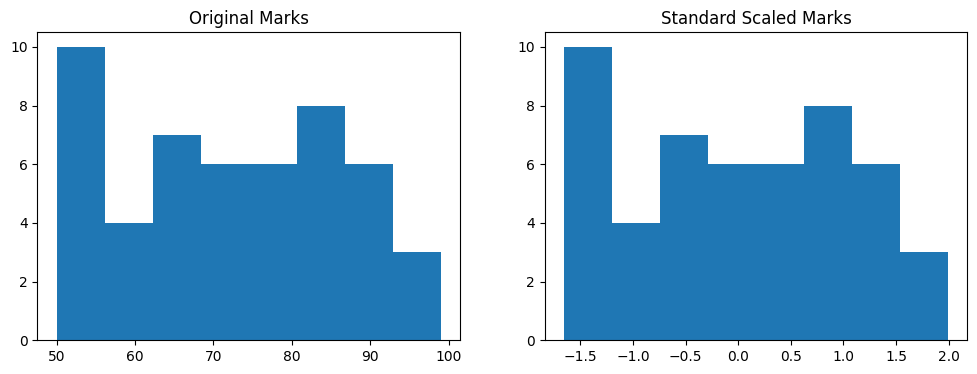

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df["Marks"], bins=8)
plt.title("Original Marks")

plt.subplot(1,2,2)
plt.hist(standard_df["Marks"], bins=8)
plt.title("Standard Scaled Marks")

plt.show()

In [10]:
feature_df = pd.get_dummies(df, drop_first=True)

X = feature_df.drop("Pass", axis=1)
y = feature_df["Pass"]

selector = SelectKBest(score_func=f_classif, k=5)

selector.fit(X, y)

selected = X.columns[selector.get_support()]

print("Top 5 Features")

for feature in selected:
    print(feature)

Top 5 Features
Gender_Label
Performance_Ordinal
Department_ISE
Performance_Poor
Gender_Male


In [11]:
print("Feature Selection Summary")
print("--------------------------")
print("Age influences maturity and experience.")
print("Study_Hours reflects learning effort.")
print("Marks directly indicate academic performance.")
print("Department may affect learning environment.")
print("Performance category helps distinguish student achievement.")

Feature Selection Summary
--------------------------
Age influences maturity and experience.
Study_Hours reflects learning effort.
Marks directly indicate academic performance.
Department may affect learning environment.
Performance category helps distinguish student achievement.


In [12]:
feature_df.to_csv("scaled_selected_dataset.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.
